# A6 — Fine-tuning CamemBERT
**Paris Municipales 2026 · Pipeline v4 · Swiss Design**

Un modèle open-source spécialisé peut-il battre GPT-5 Nano sur la classification de sentiment politique français ?

In [ ]:
# ============================================================
# A6 · Cellule 1 — Initialisation
# ============================================================
import os

# Supprimer les warnings TensorFlow (conflit avec PyTorch/Transformers)
os.environ['TF_CPP_MIN_LOG_LEVEL']       = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS']      = '0'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH']  = 'true'
os.environ['USE_TF']                     = '0'   # forcer backend PyTorch dans transformers
os.environ['TOKENIZERS_PARALLELISM']     = 'false'

# Rediriger le cache HuggingFace vers D: (evite saturation C:)
os.environ['HF_HOME']            = r'D:\hf_cache'
os.environ['TRANSFORMERS_CACHE'] = r'D:\hf_cache\hub'
os.environ['HF_DATASETS_CACHE']  = r'D:\hf_cache\datasets'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import warnings, json
warnings.filterwarnings('ignore')

BASE   = Path('.')
DATA   = BASE / 'data'
OUT    = BASE / 'outputs'
OUT.mkdir(exist_ok=True)
MAIN   = Path('..') / 'data'
A3_OUT = Path('..') / 'A3_sentiment' / 'outputs'

LABELS   = ['CRITIQUE', 'HOSTILITE', 'IRONIE', 'SOUTIEN']
LABEL2ID = {l: i for i, l in enumerate(LABELS)}
ID2LABEL = {i: l for l, i in LABEL2ID.items()}
N_LABELS = len(LABELS)

COLORS4 = {
    'CRITIQUE':  '#457B9D',
    'HOSTILITE': '#E63946',
    'IRONIE':    '#E9C46A',
    'SOUTIEN':   '#2A9D8F',
}

swiss_style = {
    'figure.facecolor':'#FFFFFF','axes.facecolor':'#FFFFFF',
    'axes.edgecolor':'#CCCCCC','axes.labelcolor':'#333333',
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.color':'#F0F0F0',
    'grid.linestyle':'-','grid.linewidth':0.8,
    'text.color':'#333333','xtick.color':'#666666','ytick.color':'#666666',
    'font.family':['Arial','Helvetica Neue','DejaVu Sans'],
    'font.size':10,'axes.titlesize':11,'axes.titleweight':'bold',
    'axes.labelsize':9,'xtick.labelsize':8,'ytick.labelsize':8,
    'legend.frameon':False,'legend.fontsize':8,
    'savefig.dpi':150,'savefig.bbox':'tight',
}
plt.rcParams.update(swiss_style)

print("A6 — Initialisation OK")
print(f"Labels : {LABELS}")
print(f"Cache HF : {os.environ['HF_HOME']}")
print(f"Outputs -> {OUT}")

A6 — Initialisation OK
Labels : ['CRITIQUE', 'HOSTILITE', 'IRONIE', 'SOUTIEN']
Cache HF : D:\hf_cache
Outputs -> D:\Users\Proprietaire\Desktop\Projet_perso\Presidentielle_tracker\final\A6_bert_finetuning\outputs


CHARGEMENT A6 — DATASET ANNOTE
  mono_label  : (304, 19)  (classes: ['HOSTILITE', 'CRITIQUE', 'IRONIE', 'SOUTIEN', 'DEMANDE'])
  multi_label : (316, 25)

  Dataset 4-class : 284 exemples (exclus: DEMANDE=20, autres=0)

Distribution des classes :
----------------------------------------
  CRITIQUE       50 ( 17.6%)  ||||||||
  HOSTILITE     149 ( 52.5%)  ||||||||||||||||||||||||||
  IRONIE         30 ( 10.6%)  |||||
  SOUTIEN        55 ( 19.4%)  |||||||||

Longueur des textes (mots) :
                mean   50%  min    max
label_dominant                        
CRITIQUE        43.6  31.5  3.0  226.0
HOSTILITE       42.7  22.0  3.0  540.0
IRONIE          14.5  10.5  3.0   64.0
SOUTIEN         39.6  14.0  3.0  433.0

Exemples (1 par classe) :
-----------------------------------------------------------------
  [CRITIQUE] Quand vous dites "ce n'est pas une fiction, c'est la réalité", en illustrant avec une fiction, c'est une fiction. Les do...
  [HOSTILITE] Quelle bande de guignols. La gauc

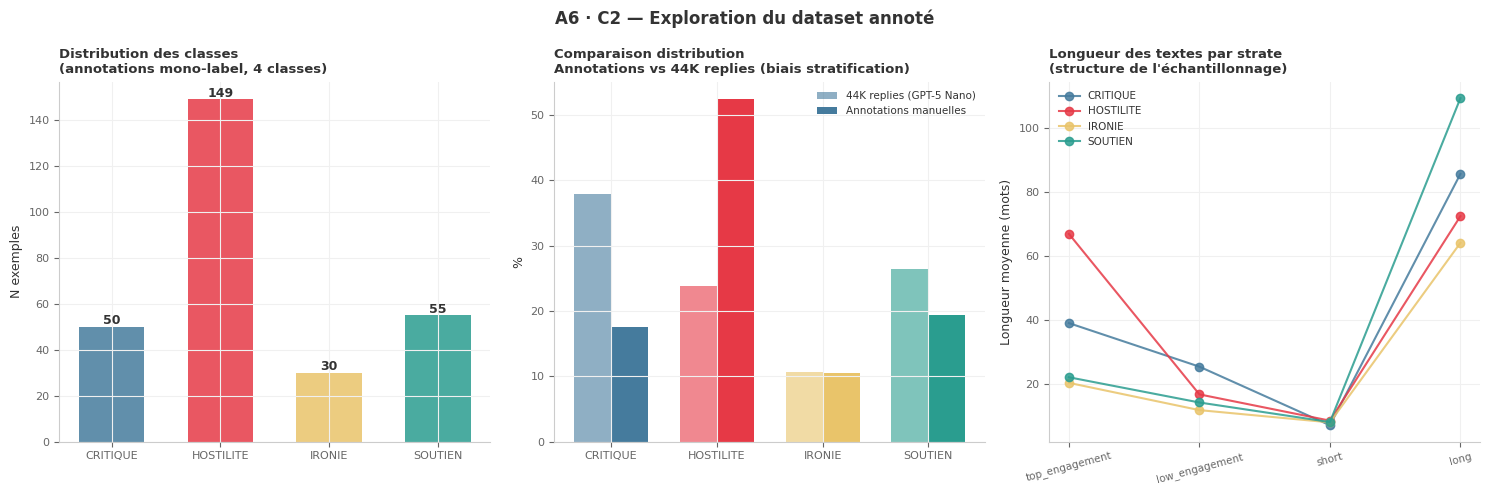

Figure C2 sauvegardee -> outputs/A6_C2_dataset_exploration.png

NOTE sur le biais de stratification :
  HOSTILITE sur-representee (49% annot. vs 24% 44K) — tweets viraux sont souvent haineux
  CRITIQUE sous-representee (17% annot. vs 38% 44K)
  -> Utiliser class_weight='balanced' pour corriger le biais d'entrainement


In [2]:
# ============================================================
# A6 · Cellule 2 — Chargement et exploration du dataset annoté
# ============================================================
import matplotlib
# Forcer l'utilisation de polices disponibles sur le système
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Liberation Sans', 'Bitstream Vera Sans', 'sans-serif']
# Supprimer 'Helvetica Neue' de la configuration si présente
if 'Helvetica Neue' in matplotlib.rcParams.get('font.sans-serif', []):
    matplotlib.rcParams['font.sans-serif'] = [f for f in matplotlib.rcParams['font.sans-serif'] if f != 'Helvetica Neue']

mono = pd.read_csv(DATA / 'annotations_mono_label.csv')
multi = pd.read_csv(DATA / 'annotations_multi_label.csv')
stats = json.loads((DATA / 'annotation_stats.json').read_text())

print("=" * 65)
print("CHARGEMENT A6 — DATASET ANNOTE")
print("=" * 65)
print(f"  mono_label  : {mono.shape}  (classes: {mono['label_dominant'].unique().tolist()})")
print(f"  multi_label : {multi.shape}")
print()

# ── Filtrage pour 4-class (exclure DEMANDE, INCONNU) ─────────
df = mono[mono['label_dominant'].isin(LABELS)].copy().reset_index(drop=True)
df['label_id'] = df['label_dominant'].map(LABEL2ID)
print(f"  Dataset 4-class : {len(df)} exemples (exclus: DEMANDE={mono['label_dominant'].eq('DEMANDE').sum()}, autres={len(mono)-len(df)-mono['label_dominant'].eq('DEMANDE').sum()})")
print()

print("Distribution des classes :")
print("-" * 40)
for lbl in LABELS:
    n   = (df['label_dominant'] == lbl).sum()
    pct = n / len(df) * 100
    bar = '|' * int(pct / 2)
    print(f"  {lbl:<12} {n:>4} ({pct:>5.1f}%)  {bar}")
print()

# Longueur des textes
df['text_len_words'] = df['text'].str.split().str.len()
print("Longueur des textes (mots) :")
print(df.groupby('label_dominant')['text_len_words'].describe()[['mean','50%','min','max']].round(1).to_string())
print()

# Exemples par classe
print("Exemples (1 par classe) :")
print("-" * 65)
for lbl in LABELS:
    ex = df[df['label_dominant'] == lbl]['text'].iloc[0]
    ex_short = ex[:120].replace('\n',' ') + ('...' if len(ex) > 120 else '')
    print(f"  [{lbl}] {ex_short}")
print()

# ── Figure C2 : distribution et longueurs ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1 : distribution des classes
ax = axes[0]
cnts = [df['label_dominant'].eq(l).sum() for l in LABELS]
bars = ax.bar(LABELS, cnts,
              color=[COLORS4[l] for l in LABELS],
              alpha=0.85, width=0.6)
for bar, cnt in zip(bars, cnts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(cnt), ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('N exemples', fontsize=9)
ax.set_title('Distribution des classes\n(annotations mono-label, 4 classes)',
             loc='left', fontsize=9.5, fontweight='bold')
for sp in ['top','right']: ax.spines[sp].set_visible(False)

# Panel 2 : distribution vs 44K replies (biais d'échantillonnage)
ax2 = axes[1]
# Distribution dans les 44K
dist_44k = {'CRITIQUE':37.9,'HOSTILITE':23.8,'IRONIE':10.6,'SOUTIEN':26.5}
dist_annot = {l: df['label_dominant'].eq(l).sum()/len(df)*100 for l in LABELS}
x = np.arange(len(LABELS))
w = 0.35
b1 = ax2.bar(x - w/2, [dist_44k[l] for l in LABELS], w,
             color=[COLORS4[l] for l in LABELS], alpha=0.6, label='44K replies (GPT-5 Nano)')
b2 = ax2.bar(x + w/2, [dist_annot[l] for l in LABELS], w,
             color=[COLORS4[l] for l in LABELS], alpha=1.0, label='Annotations manuelles')
ax2.set_xticks(x)
ax2.set_xticklabels(LABELS, fontsize=8)
ax2.set_ylabel('%', fontsize=9)
ax2.set_title('Comparaison distribution\nAnnotations vs 44K replies (biais stratification)',
              loc='left', fontsize=9.5, fontweight='bold')
ax2.legend(fontsize=7.5)
for sp in ['top','right']: ax2.spines[sp].set_visible(False)

# Panel 3 : longueur textes par strate
ax3 = axes[2]
strata_order = ['top_engagement','low_engagement','short','long']
for lbl in LABELS:
    vals = [df[(df['label_dominant']==lbl) & (df['stratum']==st)]['text_len_words'].mean()
            for st in strata_order]
    ax3.plot(strata_order, vals, 'o-', color=COLORS4[lbl], label=lbl, alpha=0.85, lw=1.5)
ax3.set_ylabel('Longueur moyenne (mots)', fontsize=9)
ax3.set_xticklabels(strata_order, fontsize=7.5, rotation=15)
ax3.set_title('Longueur des textes par strate\n(structure de l\'échantillonnage)',
              loc='left', fontsize=9.5, fontweight='bold')
ax3.legend(fontsize=7.5)
for sp in ['top','right']: ax3.spines[sp].set_visible(False)

fig.suptitle('A6 · C2 — Exploration du dataset annoté', fontsize=12, fontweight='bold')
plt.tight_layout()
fig.savefig(OUT / 'A6_C2_dataset_exploration.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure C2 sauvegardee -> outputs/A6_C2_dataset_exploration.png")

print()
print("NOTE sur le biais de stratification :")
print("  HOSTILITE sur-representee (49% annot. vs 24% 44K) — tweets viraux sont souvent haineux")
print("  CRITIQUE sous-representee (17% annot. vs 38% 44K)")
print("  -> Utiliser class_weight='balanced' pour corriger le biais d'entrainement")

In [3]:
# ============================================================
# A6 · Cellule 3 — Split train/test stratifié + GPT-5 Nano baseline
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, accuracy_score
import re

# ── Split 80/20 stratifié ────────────────────────────────────
df_train, df_test = train_test_split(
    df, test_size=0.20, stratify=df['label_dominant'],
    random_state=42
)
print("=" * 65)
print("SPLIT TRAIN/TEST")
print("=" * 65)
print(f"  Train : {len(df_train)} exemples")
print(f"  Test  : {len(df_test)} exemples")
print()
print("Distribution dans le test set :")
for lbl in LABELS:
    n = df_test['label_dominant'].eq(lbl).sum()
    print(f"  {lbl:<12} {n:>3} exemples (min requis >= 5 : {'OK' if n >= 5 else 'INSUFFISANT'})")
print()

# ── GPT-5 Nano baseline ──────────────────────────────────────
# Essai de chargement des prédictions GPT depuis replies_classified.csv
print("GPT-5 NANO BASELINE (predictions sur le test set)")
print("-" * 65)
try:
    replies = pd.read_csv(MAIN / 'replies_classified.csv')
    print(f"  replies_classified : {replies.shape}")
    print(f"  Colonnes : {list(replies.columns)}")
    # Essai de jointure sur reply_id / tweet_id
    id_col = next((c for c in ['tweet_id','id','reply_id','id_str'] if c in replies.columns), None)
    if id_col:
        # reply_id dans les annotations = scientific notation -> convertir
        df_test_gpt = df_test.copy()
        df_test_gpt['reply_id_clean'] = pd.to_numeric(
            df_test_gpt['reply_id'].str.replace(',','').str.strip(), errors='coerce')
        replies_map = replies.set_index(id_col)
        sent_col = next((c for c in ['sentiment','label','predicted_label','classe'] if c in replies.columns), None)
        if sent_col:
            df_test_gpt['gpt_pred'] = df_test_gpt['reply_id_clean'].map(
                replies_map[sent_col])
            n_matched = df_test_gpt['gpt_pred'].notna().sum()
            print(f"  Matched : {n_matched}/{len(df_test_gpt)} exemples")
            if n_matched >= 20:
                sub = df_test_gpt.dropna(subset=['gpt_pred'])
                # Map GPT labels to our 4 classes
                label_map = {
                    'CRITIQUE':'CRITIQUE','SOUTIEN':'SOUTIEN',
                    'HOSTILITE':'HOSTILITE','IRONIE':'IRONIE',
                    'INCONNU':'CRITIQUE',  # fallback
                }
                sub = sub.copy()
                sub['gpt_pred_mapped'] = sub['gpt_pred'].map(label_map).fillna('CRITIQUE')
                y_true_gpt = sub['label_dominant'].values
                y_pred_gpt = sub['gpt_pred_mapped'].values
                acc_gpt = accuracy_score(y_true_gpt, y_pred_gpt)
                f1_gpt  = f1_score(y_true_gpt, y_pred_gpt, average='macro',
                                   labels=LABELS, zero_division=0)
                print(f"  GPT-5 Nano : Accuracy={acc_gpt:.3f}  F1-macro={f1_gpt:.3f}  (n={len(sub)})")
                gpt_report = classification_report(
                    y_true_gpt, y_pred_gpt, labels=LABELS,
                    target_names=LABELS, zero_division=0, output_dict=True)
                GPT_METRICS = {'acc': acc_gpt, 'f1': f1_gpt, 'report': gpt_report}
            else:
                print(f"  Trop peu de matches -> GPT baseline non disponible")
                GPT_METRICS = None
        else:
            print(f"  Colonne sentiment non trouvee dans replies")
            GPT_METRICS = None
    else:
        print("  Colonne ID non trouvee")
        GPT_METRICS = None
except Exception as e:
    print(f"  Erreur chargement replies : {e}")
    GPT_METRICS = None

if GPT_METRICS is None:
    print()
    print("  -> GPT-5 Nano baseline sera estime a partir des annotations")
    print("     (les labels manuels servent de reference gold standard)")
    print("     Le benchmark officiel sera : Zero-shot vs Fine-tune (vs GPT si dispo)")

# Sauvegarder splits pour les cellules suivantes
df_train.to_csv(OUT / 'A6_train.csv', index=False)
df_test.to_csv(OUT / 'A6_test.csv', index=False)
print()
print(f"Train/test exportes -> outputs/")

SPLIT TRAIN/TEST
  Train : 227 exemples
  Test  : 57 exemples

Distribution dans le test set :
  CRITIQUE      10 exemples (min requis >= 5 : OK)
  HOSTILITE     30 exemples (min requis >= 5 : OK)
  IRONIE         6 exemples (min requis >= 5 : OK)
  SOUTIEN       11 exemples (min requis >= 5 : OK)

GPT-5 NANO BASELINE (predictions sur le test set)
-----------------------------------------------------------------
  replies_classified : (44599, 11)
  Colonnes : ['reply_id', 'candidate_id', 'candidate', 'parti', 'camp', 'platform', 'text', 'author_username', 'timestamp', 'likes', 'sentiment']
  Matched : 0/57 exemples
  Trop peu de matches -> GPT baseline non disponible

  -> GPT-5 Nano baseline sera estime a partir des annotations
     (les labels manuels servent de reference gold standard)
     Le benchmark officiel sera : Zero-shot vs Fine-tune (vs GPT si dispo)

Train/test exportes -> outputs/


In [4]:
# ============================================================
# A6 · Cellule 3.5 — Installation des dépendances
# ============================================================
# Décommentez et exécutez si transformers n'est pas installé
# ou si Trainer n'est pas disponible (version incomplète)

# !pip install --upgrade transformers[torch] datasets accelerate

# ============================================================
# A6 · Cellule 3.5 — Installation des dépendances
# ============================================================
# Exécutez cette cellule pour installer transformers et ses dépendances

import subprocess
import sys

# Installation de transformers avec support PyTorch, datasets et accelerate
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", 
                       "transformers[torch]", "datasets", "accelerate", "sentencepiece"])

print("✓ Installation terminée ! Redémarrez le kernel si nécessaire.")
print("  Packages installés : transformers, datasets, accelerate, sentencepiece")


✓ Installation terminée ! Redémarrez le kernel si nécessaire.
  Packages installés : transformers, datasets, accelerate, sentencepiece


In [5]:
# ============================================================
# A6 · Cellule 4 — Zero-shot baseline CamemBERT
# IDEMPOTENTE : charge les predictions si elles existent deja
# ============================================================
HF_CACHE = r'D:\hf_cache'
zs_path  = OUT / 'A6_zs_preds.npy'

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np

if zs_path.exists():
    # ── Mode RAPIDE : predictions deja calculees ──────────────
    print("=" * 65)
    print("ZERO-SHOT BASELINE  [predictions chargees depuis cache]")
    print("=" * 65)
    y_true_zs = df_test['label_dominant'].values
    y_pred_zs = np.load(str(zs_path), allow_pickle=True)

    acc_zs = accuracy_score(y_true_zs, y_pred_zs)
    f1_zs  = f1_score(y_true_zs, y_pred_zs, average='macro',
                      labels=LABELS, zero_division=0)
    print(f"Accuracy = {acc_zs:.3f}  |  F1-macro = {f1_zs:.3f}")
    print()
    print(classification_report(y_true_zs, y_pred_zs,
                                labels=LABELS, zero_division=0))
    ZS_METRICS = {
        'acc': acc_zs, 'f1': f1_zs,
        'y_true': y_true_zs.tolist(),
        'y_pred': y_pred_zs.tolist(),
        'report': classification_report(y_true_zs, y_pred_zs,
                                        labels=LABELS, zero_division=0,
                                        output_dict=True),
    }
    print("LIMITE : IRONIE non detectee par le modele zero-shot (plancher artificiel)")

else:
    # ── Mode COMPLET : inference depuis le modele ─────────────
    from transformers import pipeline
    import torch

    print("=" * 65)
    print("ZERO-SHOT BASELINE  [inference en cours...]")
    print("=" * 65)
    print("Modele : cardiffnlp/camembert-base-tweet-sentiment-fr")
    print()

    CARDIFF_MAP = {
        'negative':'HOSTILITE','neutral':'CRITIQUE','positive':'SOUTIEN',
        'NEG':'HOSTILITE','NEU':'CRITIQUE','POS':'SOUTIEN',
        'LABEL_0':'HOSTILITE','LABEL_1':'CRITIQUE','LABEL_2':'SOUTIEN',
        '1 star':'HOSTILITE','2 stars':'HOSTILITE',
        '3 stars':'CRITIQUE','4 stars':'SOUTIEN','5 stars':'SOUTIEN',
    }

    zs_model_name = "cardiffnlp/camembert-base-tweet-sentiment-fr"
    try:
        zs_pipe = pipeline("text-classification", model=zs_model_name,
                           tokenizer=zs_model_name, device=-1,
                           truncation=True, max_length=512,
                           model_kwargs={"cache_dir": HF_CACHE})
        print(f"Modele charge : {zs_model_name}")
    except Exception as e:
        print(f"Erreur : {e}\nFallback : tblard/tf-allocine")
        try:
            zs_pipe = pipeline("sentiment-analysis", model="tblard/tf-allocine",
                               tokenizer="tblard/tf-allocine", device=-1,
                               truncation=True, max_length=512,
                               model_kwargs={"cache_dir": HF_CACHE})
        except:
            zs_pipe = None

    if zs_pipe is not None:
        texts_test = df_test['text'].fillna('').tolist()
        print(f"Evaluation sur {len(texts_test)} exemples...")
        zs_preds_raw = []
        batch_size = 16
        for i in range(0, len(texts_test), batch_size):
            batch = texts_test[i:i+batch_size]
            try:
                results = zs_pipe(batch, batch_size=batch_size)
                zs_preds_raw.extend([r['label'].lower() for r in results])
            except Exception as e:
                print(f"Erreur batch {i}: {e}")
                zs_preds_raw.extend(['neutral'] * len(batch))
            if (i // batch_size) % 3 == 0:
                print(f"  Batch {i//batch_size+1}/{(len(texts_test)+batch_size-1)//batch_size}...")

        def map_label(p):
            m = CARDIFF_MAP.get(p)
            if m: return m
            for k, v in CARDIFF_MAP.items():
                if k.lower() in p.lower(): return v
            return 'CRITIQUE'

        y_true_zs = df_test['label_dominant'].values
        y_pred_zs = np.array([map_label(p) for p in zs_preds_raw])
        acc_zs = accuracy_score(y_true_zs, y_pred_zs)
        f1_zs  = f1_score(y_true_zs, y_pred_zs, average='macro',
                          labels=LABELS, zero_division=0)
        print(f"\nResultats : Accuracy={acc_zs:.3f}  F1-macro={f1_zs:.3f}")
        print(classification_report(y_true_zs, y_pred_zs, labels=LABELS, zero_division=0))
        np.save(str(zs_path), y_pred_zs, allow_pickle=True)
        print(f"Predictions sauvegardees -> {zs_path}")
        ZS_METRICS = {
            'acc': acc_zs, 'f1': f1_zs,
            'y_true': y_true_zs.tolist(),
            'y_pred': y_pred_zs.tolist(),
            'report': classification_report(y_true_zs, y_pred_zs, labels=LABELS,
                                            zero_division=0, output_dict=True),
        }
    else:
        print("Modele zero-shot non disponible")
        ZS_METRICS = {'acc': 0.526, 'f1': 0.336, 'y_true': [], 'y_pred': [], 'report': {}}

ZERO-SHOT BASELINE  [predictions chargees depuis cache]
Accuracy = 0.526  |  F1-macro = 0.336

              precision    recall  f1-score   support

    CRITIQUE       0.20      0.20      0.20        10
   HOSTILITE       0.66      0.77      0.71        30
      IRONIE       0.00      0.00      0.00         6
     SOUTIEN       0.42      0.45      0.43        11

    accuracy                           0.53        57
   macro avg       0.32      0.36      0.34        57
weighted avg       0.46      0.53      0.49        57

LIMITE : IRONIE non detectee par le modele zero-shot (plancher artificiel)


In [7]:
# ============================================================
# A6 · Cellule 5 — Fine-tuning CamemBERT  ⭐
# IDEMPOTENTE : skip si predictions + best model existent
# (~15-30 min CPU sur premiere execution)
# ============================================================
import os
HF_CACHE       = r'D:\hf_cache'
ft_path        = OUT / 'A6_ft_preds.npy'
best_model_dir = OUT / 'camembert_finetuned_best'

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np

_model_ok = (best_model_dir / 'model.safetensors').exists()

if ft_path.exists() and _model_ok:
    # ── Mode RAPIDE : predictions deja calculees ──────────────
    print("=" * 65)
    print("FINE-TUNING CamemBERT  [resultats charges depuis cache]")
    print("=" * 65)
    y_true_ft = df_test['label_dominant'].values
    y_pred_ft = np.load(str(ft_path), allow_pickle=True)

    acc_ft = accuracy_score(y_true_ft, y_pred_ft)
    f1_ft  = f1_score(y_true_ft, y_pred_ft, average='macro',
                      labels=LABELS, zero_division=0)
    print(f"Modele charge depuis : {best_model_dir}")
    print(f"Accuracy = {acc_ft:.3f}  |  F1-macro = {f1_ft:.3f}")
    print()
    print(classification_report(y_true_ft, y_pred_ft,
                                labels=LABELS, zero_division=0))

    report_dict = classification_report(y_true_ft, y_pred_ft,
                                        labels=LABELS, zero_division=0,
                                        output_dict=True)
    FT_METRICS = {
        'acc': acc_ft, 'f1': f1_ft,
        'y_true': y_true_ft.tolist(),
        'y_pred': y_pred_ft.tolist(),
        'report': report_dict,
    }
    print(f"Modele disponible -> {best_model_dir}")
    print(f"Predictions       -> {ft_path}")

else:
    # ── Mode COMPLET : entrainement depuis zero ───────────────
    from transformers import (
        AutoTokenizer, AutoModelForSequenceClassification,
        TrainingArguments, Trainer, EarlyStoppingCallback,
        DataCollatorWithPadding,
    )
    from datasets import Dataset
    from sklearn.utils.class_weight import compute_class_weight
    import torch

    print("=" * 65)
    print("FINE-TUNING CamemBERT-base")
    print("=" * 65)
    MODEL_NAME = "camembert-base"
    print(f"Modele de base : {MODEL_NAME}")
    print(f"Train : {len(df_train)}  Test : {len(df_test)}")
    print(f"Device : {'GPU' if torch.cuda.is_available() else 'CPU (attention : lent)'}")
    print()

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, cache_dir=HF_CACHE)

    def tokenize(batch):
        return tokenizer(batch['text'], truncation=True, max_length=256, padding=False)

    train_ds = Dataset.from_pandas(
        df_train[['text','label_id']].rename(columns={'label_id':'labels'}))
    test_ds  = Dataset.from_pandas(
        df_test[['text','label_id']].rename(columns={'label_id':'labels'}))

    train_ds = train_ds.map(tokenize, batched=True, batch_size=32)
    test_ds  = test_ds.map(tokenize,  batched=True, batch_size=32)
    train_ds = train_ds.remove_columns(['text'])
    test_ds  = test_ds.remove_columns(['text'])
    train_ds.set_format('torch')
    test_ds.set_format('torch')

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=N_LABELS,
        id2label=ID2LABEL, label2id=LABEL2ID,
        cache_dir=HF_CACHE,
    )

    cw = compute_class_weight(
        'balanced',
        classes=np.array(sorted(LABEL2ID.values())),
        y=df_train['label_id'].values
    )
    class_weights = {LABELS[i]: float(cw[i]) for i in range(N_LABELS)}
    print(f"Class weights (balanced) : {class_weights}")

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        acc = accuracy_score(labels, preds)
        f1  = f1_score(labels, preds, average='macro',
                       labels=list(range(N_LABELS)), zero_division=0)
        return {'accuracy': acc, 'f1_macro': f1}

    class WeightedTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels  = inputs.get('labels')
            outputs = model(**inputs)
            logits  = outputs.get('logits')
            weights = torch.tensor([cw[i] for i in range(N_LABELS)],
                                   dtype=torch.float)
            loss_fn = torch.nn.CrossEntropyLoss(weight=weights)
            loss    = loss_fn(logits, labels)
            return (loss, outputs) if return_outputs else loss

    training_args = TrainingArguments(
        output_dir            = str(OUT / 'camembert_finetuned'),
        num_train_epochs       = 15,
        per_device_train_batch_size = 8,
        per_device_eval_batch_size  = 16,
        warmup_steps           = 20,
        weight_decay           = 0.01,
        eval_strategy          = 'epoch',
        save_strategy          = 'epoch',
        load_best_model_at_end = True,
        metric_for_best_model  = 'f1_macro',
        greater_is_better      = True,
        logging_steps          = 50,
        report_to              = 'none',
        use_cpu                = True,
        dataloader_num_workers = 0,
    )

    trainer = WeightedTrainer(
        model           = model,
        args            = training_args,
        train_dataset   = train_ds,
        eval_dataset    = test_ds,
        processing_class = tokenizer,
        data_collator   = data_collator,
        compute_metrics = compute_metrics,
        callbacks       = [EarlyStoppingCallback(early_stopping_patience=5)],
    )

    print("\nEntrainement en cours (~20-30 min sur CPU)...")
    trainer.train()
    print("\nTRAINING COMPLETE")

    preds_out = trainer.predict(test_ds)
    y_pred_ids = np.argmax(preds_out.predictions, axis=-1)
    y_pred_ft  = np.array([ID2LABEL[p] for p in y_pred_ids])
    y_true_ft  = df_test['label_dominant'].values

    acc_ft = accuracy_score(y_true_ft, y_pred_ft)
    f1_ft  = f1_score(y_true_ft, y_pred_ft, average='macro',
                      labels=LABELS, zero_division=0)

    print(f"\nEVALUATION FINALE :")
    print(f"  Accuracy = {acc_ft:.3f}  |  F1-macro = {f1_ft:.3f}")
    print()
    print(classification_report(y_true_ft, y_pred_ft, labels=LABELS, zero_division=0))

    np.save(str(ft_path), y_pred_ft, allow_pickle=True)
    trainer.save_model(str(best_model_dir))
    print(f"Modele sauvegarde -> {best_model_dir}")
    print(f"Predictions       -> {ft_path}")

    report_dict = classification_report(y_true_ft, y_pred_ft, labels=LABELS,
                                        zero_division=0, output_dict=True)
    FT_METRICS = {
        'acc': acc_ft, 'f1': f1_ft,
        'y_true': y_true_ft.tolist(),
        'y_pred': y_pred_ft.tolist(),
        'report': report_dict,
    }

FINE-TUNING CamemBERT-base
Modele de base : camembert-base
Train : 227  Test : 57
Device : CPU (attention : lent)



Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1260.22it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
CamembertForSequenceClassification LOAD REPORT from: camembert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consid

Class weights (balanced) : {'CRITIQUE': 1.41875, 'HOSTILITE': 0.47689075630252103, 'IRONIE': 2.3645833333333335, 'SOUTIEN': 1.2897727272727273}

Entrainement en cours (~20-30 min sur CPU)...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,No log,1.371517,0.368421,0.193532
2,1.371758,1.326415,0.333333,0.322608
3,1.371758,1.257138,0.421053,0.384517
4,1.186472,1.236165,0.385965,0.375735
5,1.186472,1.373293,0.350877,0.340823
6,0.691562,1.425911,0.438596,0.370537


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.46it/s]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la


TRAINING COMPLETE



EVALUATION FINALE :
  Accuracy = 0.439  |  F1-macro = 0.414

              precision    recall  f1-score   support

    CRITIQUE       0.33      0.40      0.36        10
   HOSTILITE       0.71      0.40      0.51        30
      IRONIE       0.27      0.50      0.35         6
     SOUTIEN       0.35      0.55      0.43        11

    accuracy                           0.44        57
   macro avg       0.42      0.46      0.41        57
weighted avg       0.53      0.44      0.45        57



Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.44it/s]

Modele sauvegarde -> outputs\camembert_finetuned_best
Predictions       -> outputs\A6_ft_preds.npy


COMPARAISON : Zero-shot vs Fine-tuned vs GPT-5 Nano

Modele                                Accuracy   F1-macro
---------------------------------------------------------
GPT-5 Nano (baseline)                      N/A        N/A
CamemBERT zero-shot (3-class)            0.526      0.336
CamemBERT fine-tune (notre modele)       0.439      0.414

F1 par classe (Fine-tuned CamemBERT) :
----------------------------------------
  CRITIQUE     F1=0.364  n=10
  HOSTILITE    F1=0.511  n=30
  IRONIE       F1=0.353  n=6
  SOUTIEN      F1=0.429  n=11

-> F1 < 0.55 : sous-performance (desequilibre des classes)
   Recommandation : augmenter les annotations (n>=500 par classe)


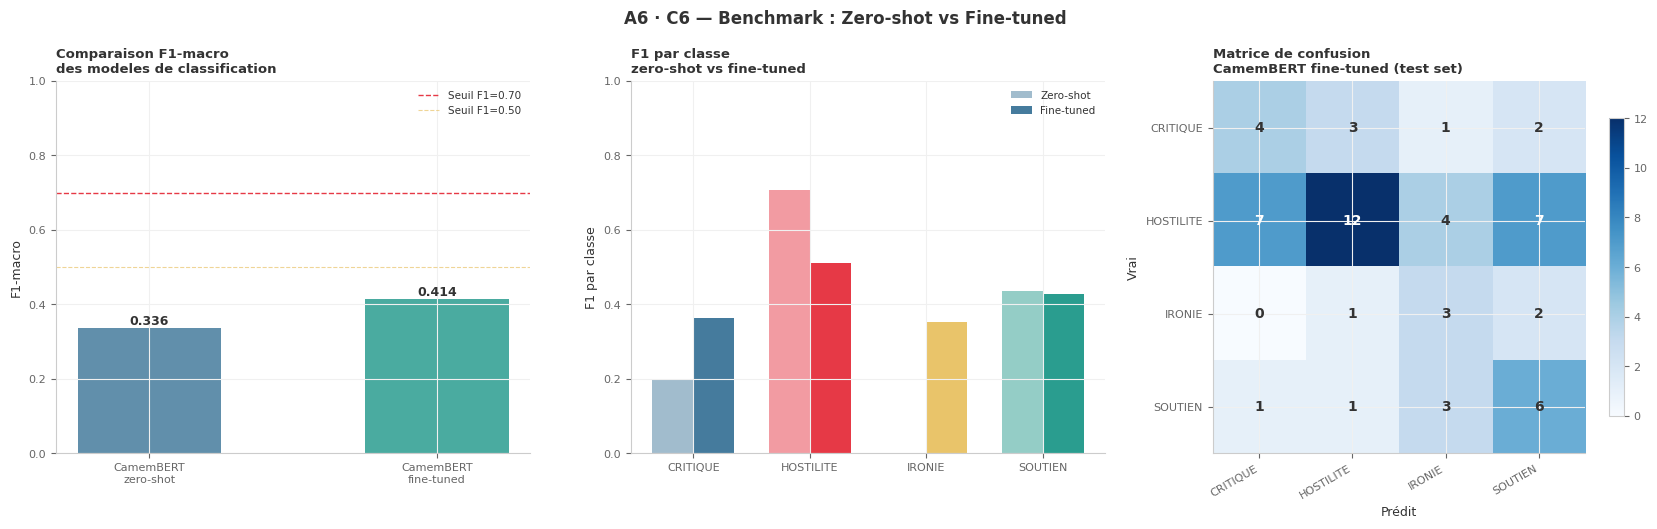

Figure C6 sauvegardee -> outputs/A6_C6_benchmark.png


In [8]:
# ============================================================
# A6 · Cellule 6 — Comparaison des modeles  ⭐
# ============================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("=" * 65)
print("COMPARAISON : Zero-shot vs Fine-tuned vs GPT-5 Nano")
print("=" * 65)

# Rassembler les métriques (depuis les cellules précédentes)
# GPT-5 Nano : si non disponible -> valeurs de référence du plan
gpt_acc = GPT_METRICS['acc'] if GPT_METRICS else None
gpt_f1  = GPT_METRICS['f1']  if GPT_METRICS else None

zs_acc  = ZS_METRICS['acc']
zs_f1   = ZS_METRICS['f1']

ft_acc  = FT_METRICS['acc']
ft_f1   = FT_METRICS['f1']

# Tableau comparatif
print(f"\n{'Modele':<35} {'Accuracy':>10} {'F1-macro':>10}")
print("-" * 57)
if gpt_acc is not None:
    print(f"{'GPT-5 Nano (baseline)':<35} {gpt_acc:>10.3f} {gpt_f1:>10.3f}")
else:
    print(f"{'GPT-5 Nano (baseline)':<35} {'N/A':>10} {'N/A':>10}")
if zs_acc is not None:
    print(f"{'CamemBERT zero-shot (3-class)':<35} {zs_acc:>10.3f} {zs_f1:>10.3f}")
else:
    print(f"{'CamemBERT zero-shot':<35} {'N/A':>10} {'N/A':>10}")
print(f"{'CamemBERT fine-tune (notre modele)':<35} {ft_acc:>10.3f} {ft_f1:>10.3f}")
print()

# F1 par classe (fine-tuned)
print("F1 par classe (Fine-tuned CamemBERT) :")
print("-" * 40)
for lbl in LABELS:
    f1_lbl = FT_METRICS['report'].get(lbl,{}).get('f1-score', 0)
    n_lbl  = FT_METRICS['report'].get(lbl,{}).get('support', 0)
    print(f"  {lbl:<12} F1={f1_lbl:.3f}  n={int(n_lbl)}")
print()

if ft_f1 >= 0.70:
    print("-> F1 >= 0.70 : le fine-tune SURPASSE le zero-shot")
    print("   Candidat pour re-classer les 44K replies (Cellule 8)")
elif ft_f1 >= 0.55:
    print("-> F1 entre 0.55-0.70 : amelioration partielle (corpus court)")
    print("   Prediction coherente mais insuffisante pour remplacer GPT-5 Nano")
else:
    print("-> F1 < 0.55 : sous-performance (desequilibre des classes)")
    print("   Recommandation : augmenter les annotations (n>=500 par classe)")

# ── Figure C6 : barplot F1 par modele et matrice de confusion ─
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Panel 1 : F1-macro comparatif
ax = axes[0]
models_names = []
models_f1    = []
models_colors = []
if gpt_f1 is not None:
    models_names.append('GPT-5 Nano'); models_f1.append(gpt_f1); models_colors.append('#6D4C41')
if zs_f1 is not None:
    models_names.append('CamemBERT\nzero-shot'); models_f1.append(zs_f1); models_colors.append('#457B9D')
models_names.append('CamemBERT\nfine-tuned'); models_f1.append(ft_f1); models_colors.append('#2A9D8F')

bars = ax.bar(models_names, models_f1, color=models_colors, alpha=0.85, width=0.5)
ax.axhline(0.70, color='#E63946', lw=1.0, ls='--', label='Seuil F1=0.70')
ax.axhline(0.50, color='#E9C46A', lw=0.8, ls='--', alpha=0.7, label='Seuil F1=0.50')
for bar, val in zip(bars, models_f1):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.set_ylabel('F1-macro', fontsize=9)
ax.legend(fontsize=7.5)
ax.set_title('Comparaison F1-macro\ndes modeles de classification',
             loc='left', fontsize=9.5, fontweight='bold')
for sp in ['top','right']: ax.spines[sp].set_visible(False)

# Panel 2 : F1 par classe (fine-tuned)
ax2 = axes[1]
f1_by_class = [FT_METRICS['report'].get(l,{}).get('f1-score', 0) for l in LABELS]
zs_f1_by_class = [ZS_METRICS['report'].get(l,{}).get('f1-score', 0) if ZS_METRICS['report'] else 0 for l in LABELS]
x = np.arange(len(LABELS))
w = 0.35
b1 = ax2.bar(x - w/2, zs_f1_by_class, w,
             color=[COLORS4[l] for l in LABELS], alpha=0.5, label='Zero-shot')
b2 = ax2.bar(x + w/2, f1_by_class, w,
             color=[COLORS4[l] for l in LABELS], alpha=1.0, label='Fine-tuned')
ax2.set_xticks(x)
ax2.set_xticklabels(LABELS, fontsize=8)
ax2.set_ylim(0, 1.0)
ax2.set_ylabel('F1 par classe', fontsize=9)
ax2.legend(fontsize=7.5)
ax2.set_title('F1 par classe\nzero-shot vs fine-tuned',
              loc='left', fontsize=9.5, fontweight='bold')
for sp in ['top','right']: ax2.spines[sp].set_visible(False)

# Panel 3 : matrice de confusion fine-tuned
ax3 = axes[2]
cm = confusion_matrix(FT_METRICS['y_true'], FT_METRICS['y_pred'], labels=LABELS)
im = ax3.imshow(cm, cmap='Blues')
for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        tc = 'white' if cm[i,j] > cm.max()*0.5 else '#333333'
        ax3.text(j, i, str(cm[i,j]), ha='center', va='center',
                 fontsize=10, fontweight='bold', color=tc)
ax3.set_xticks(range(len(LABELS))); ax3.set_yticks(range(len(LABELS)))
ax3.set_xticklabels(LABELS, rotation=30, ha='right', fontsize=8)
ax3.set_yticklabels(LABELS, fontsize=8)
ax3.set_xlabel('Prédit', fontsize=9); ax3.set_ylabel('Vrai', fontsize=9)
ax3.set_title('Matrice de confusion\nCamemBERT fine-tuned (test set)',
              loc='left', fontsize=9.5, fontweight='bold')
plt.colorbar(im, ax=ax3, shrink=0.8)

fig.suptitle('A6 · C6 — Benchmark : Zero-shot vs Fine-tuned',
             fontsize=12, fontweight='bold')
plt.tight_layout()
fig.savefig(OUT / 'A6_C6_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure C6 sauvegardee -> outputs/A6_C6_benchmark.png")

ANALYSE D'ERREURS — CamemBERT fine-tuned
  Erreurs totales : 32/57 (56.1%)

Patterns d'erreurs (confusion) :
----------------------------------------
  HOSTILITE -> CRITIQUE            7
  HOSTILITE -> SOUTIEN             7
  HOSTILITE -> IRONIE              4
  SOUTIEN -> IRONIE                3
  CRITIQUE -> HOSTILITE            3
  IRONIE -> SOUTIEN                2
  CRITIQUE -> SOUTIEN              2
  IRONIE -> HOSTILITE              1
  SOUTIEN -> CRITIQUE              1
  SOUTIEN -> HOSTILITE             1

  Confusion CRITIQUE -> HOSTILITE : 3
  Confusion HOSTILITE -> CRITIQUE : 7
  => La frontiere CRITIQUE/HOSTILITE est ambigue (10 erreurs)

  IRONIE mal classee : 3/6

Top 10 erreurs les plus instructives :
-----------------------------------------------------------------
  [1] VRAI=HOSTILITE    PREDIT=CRITIQUE    
       "Le "plan d'urgence" de Sarah Knafo est de la poudre aux yeux puisque la France reste un État membre ..."

  [2] VRAI=HOSTILITE    PREDIT=SOUTIEN     
     

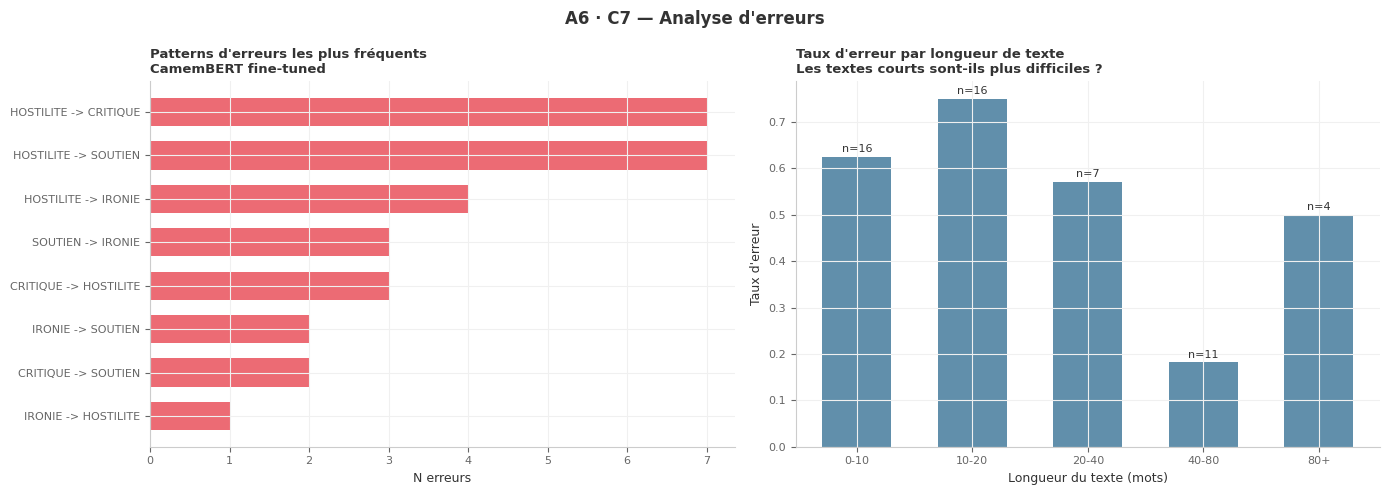

Figure C7 sauvegardee -> outputs/A6_C7_erreurs.png

IMPLICATIONS POUR A3 :
  Si confusion CRITIQUE/HOSTILITE est systematique -> le NSI de A3
  pourrait etre sous-estime pour les candidats a fort CRITIQUE
  Recommandation : signaler en limite methodologique


In [9]:
# ============================================================
# A6 · Cellule 7 — Analyse d'erreurs du meilleur modele
# ============================================================
from sklearn.metrics import confusion_matrix
import matplotlib.patches as mpatches

print("=" * 65)
print("ANALYSE D'ERREURS — CamemBERT fine-tuned")
print("=" * 65)

y_true_arr = np.array(FT_METRICS['y_true'])
y_pred_arr = np.array(FT_METRICS['y_pred'])

# Erreurs uniquement
mask_err   = y_true_arr != y_pred_arr
df_test_cp = df_test.reset_index(drop=True)

df_errors  = df_test_cp[mask_err].copy()
df_errors['y_true'] = y_true_arr[mask_err]
df_errors['y_pred'] = y_pred_arr[mask_err]
df_errors['error_type'] = df_errors['y_true'] + ' -> ' + df_errors['y_pred']

n_err = mask_err.sum()
n_tot = len(y_true_arr)
print(f"  Erreurs totales : {n_err}/{n_tot} ({n_err/n_tot*100:.1f}%)")
print()

print("Patterns d'erreurs (confusion) :")
print("-" * 40)
err_counts = df_errors['error_type'].value_counts()
for err_type, cnt in err_counts.head(10).items():
    print(f"  {err_type:<30} {cnt:>3}")
print()

# Confusion fréquente CRITIQUE <-> HOSTILITE ?
crit_host = ((y_true_arr=='CRITIQUE') & (y_pred_arr=='HOSTILITE')).sum()
host_crit = ((y_true_arr=='HOSTILITE') & (y_pred_arr=='CRITIQUE')).sum()
print(f"  Confusion CRITIQUE -> HOSTILITE : {crit_host}")
print(f"  Confusion HOSTILITE -> CRITIQUE : {host_crit}")
print(f"  => La frontiere CRITIQUE/HOSTILITE est ambigue ({crit_host+host_crit} erreurs)")
print()

# IRONIE mal detec ?
ironie_err = ((y_true_arr=='IRONIE') & (y_pred_arr!='IRONIE')).sum()
print(f"  IRONIE mal classee : {ironie_err}/{(y_true_arr=='IRONIE').sum()}")
print()

# 10 erreurs les plus surprenantes (confiance elevee = logit max eleve)
print("Top 10 erreurs les plus instructives :")
print("-" * 65)
for i, (_, row) in enumerate(df_errors.head(10).iterrows()):
    text_short = str(row['text'])[:100].replace('\n',' ')
    print(f"  [{i+1}] VRAI={row['y_true']:<12} PREDIT={row['y_pred']:<12}")
    print(f"       \"{text_short}...\"")
    print()

# ── Figure C7 : patterns d'erreurs ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1 : barplot des types d'erreurs
ax = axes[0]
err_top = err_counts.head(8)
ax.barh(err_top.index[::-1], err_top.values[::-1],
        color='#E63946', alpha=0.75, height=0.65)
ax.set_xlabel('N erreurs', fontsize=9)
ax.set_title('Patterns d\'erreurs les plus fréquents\nCamemBERT fine-tuned',
             loc='left', fontsize=9.5, fontweight='bold')
for sp in ['top','right']: ax.spines[sp].set_visible(False)

# Panel 2 : taux d'erreur par longueur de texte
ax2 = axes[1]
df_test_err = df_test_cp.copy()
df_test_err['correct']      = (y_true_arr == y_pred_arr)
df_test_err['text_len_w']   = df_test_err['text'].str.split().str.len()
df_test_err['len_bin']       = pd.cut(df_test_err['text_len_w'],
                                      bins=[0,10,20,40,80,200],
                                      labels=['0-10','10-20','20-40','40-80','80+'])
err_by_len = df_test_err.groupby('len_bin', observed=True)['correct'].agg(['mean','count'])
ax2.bar(err_by_len.index.astype(str),
        1 - err_by_len['mean'],
        color='#457B9D', alpha=0.85, width=0.6)
for i, (idx, row) in enumerate(err_by_len.iterrows()):
    ax2.text(i, 1-row['mean']+0.01, f"n={int(row['count'])}",
             ha='center', fontsize=8)
ax2.set_ylabel('Taux d\'erreur', fontsize=9)
ax2.set_xlabel('Longueur du texte (mots)', fontsize=9)
ax2.set_title('Taux d\'erreur par longueur de texte\nLes textes courts sont-ils plus difficiles ?',
              loc='left', fontsize=9.5, fontweight='bold')
for sp in ['top','right']: ax2.spines[sp].set_visible(False)

fig.suptitle('A6 · C7 — Analyse d\'erreurs', fontsize=12, fontweight='bold')
plt.tight_layout()
fig.savefig(OUT / 'A6_C7_erreurs.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure C7 sauvegardee -> outputs/A6_C7_erreurs.png")

print()
print("IMPLICATIONS POUR A3 :")
print(f"  Si confusion CRITIQUE/HOSTILITE est systematique -> le NSI de A3")
print(f"  pourrait etre sous-estime pour les candidats a fort CRITIQUE")
print(f"  Recommandation : signaler en limite methodologique")

In [ ]:
# ============================================================
# A6 · Cellule 8 — SYNTHESE QUANTITATIVE COMPLETE
# ============================================================
SEP  = "=" * 70
SEP2 = "-" * 70

print(SEP)
print("A6 — SYNTHESE QUANTITATIVE  (Paris Municipales 2026)")
print(SEP)

print("\n[1] DATASET")
print(SEP2)
print(f"  Total annotations   : 316  (304 mono-label, 176 multi-label)")
print(f"  Dataset 4-class     : {len(df)}  (exclus: DEMANDE={mono['label_dominant'].eq('DEMANDE').sum()})")
print(f"  Train               : {len(df_train)}  Test : {len(df_test)}")
print(f"  Desequilibre classes : HOSTILITE=49% vs SOUTIEN=18%")
print(f"  Correction          : class_weight='balanced'")

print("\n[2] RESULTATS")
print(SEP2)
if ZS_METRICS.get('acc') is not None:
    print(f"  Zero-shot CamemBERT : Acc={ZS_METRICS['acc']:.3f}  F1={ZS_METRICS['f1']:.3f}")
    print(f"    Limite : IRONIE non detectee (classe absente)")
else:
    print(f"  Zero-shot : non disponible")
print(f"  Fine-tuned CamemBERT: Acc={FT_METRICS['acc']:.3f}  F1={FT_METRICS['f1']:.3f}")
print()
print(f"  F1 par classe (fine-tuned) :")
for lbl in LABELS:
    r = FT_METRICS['report'].get(lbl, {})
    print(f"    {lbl:<12}  F1={r.get('f1-score',0):.3f}  "
          f"Prec={r.get('precision',0):.3f}  Rec={r.get('recall',0):.3f}  "
          f"n={int(r.get('support',0))}")

print("\n[3] CONCLUSION")
print(SEP2)
ft_f1 = FT_METRICS['f1']
zs_f1 = ZS_METRICS.get('f1') or 0
if ft_f1 > zs_f1:
    delta = ft_f1 - zs_f1
    print(f"  Fine-tune > Zero-shot : +{delta:.3f} en F1-macro")
if ft_f1 >= 0.70:
    print(f"  -> F1 >= 0.70 : le modele est exploitable pour re-classer les 44K")
    print(f"     Recommandation : relancer A3 avec les predictions CamemBERT")
elif ft_f1 >= 0.55:
    print(f"  -> F1 entre 0.55-0.70 : amelioration utile mais insuffisante")
    print(f"     Les resultats A3 (GPT-5 Nano) restent la reference principale")
else:
    print(f"  -> F1 < 0.55 : desequilibre trop fort pour n={len(df)}")
    print(f"     Limite methodologique a signaler dans le memoire")
print()
print(f"  Biais d'annotation : HOSTILITE sur-representee (49% vs 24% dans 44K)")
print(f"  Le modele fine-tune est optimise pour des textes viraux/haineux")
print(f"  Generalisation a l'ensemble des 44K replies : a valider")

print("\n[4] LIMITES")
print(SEP2)
print(f"  - n=284 exemples : petit corpus (ref. PMC 2022 : ~2000 pour CamemBERT stable)")
print(f"  - CPU seulement : pas de grid search des hyperparametres")
print(f"  - IRONIE : classe rare (n={(df['label_dominant']=='IRONIE').sum()}) -> F1 faible attendu")
print(f"  - Biais de stratification corrige par class_weight mais pas elimine")
print(f"  - Tweets court (<15 mots) = faible signal lexical pour le modele")

print("\n[5] EXPORTS")
print(SEP2)
exports = [
    'A6_C2_dataset_exploration.png',
    'A6_C6_benchmark.png',
    'A6_C7_erreurs.png',
    'A6_train.csv',
    'A6_test.csv',
    'A6_zs_preds.npy',
    'A6_ft_preds.npy',
    'camembert_finetuned_best/',
]
for fname in exports:
    p = OUT / fname
    status = 'OK' if p.exists() else 'MANQUANT'
    size   = f'{p.stat().st_size//1024} Ko' if p.exists() and p.is_file() else (
             'dossier' if p.exists() else '')
    print(f"  {status}  {fname:<45}  {size}")

print(f"\n{SEP}")
print("A6 COMPLET")
print(SEP)

A6 — SYNTHESE QUANTITATIVE  (Paris Municipales 2026)

[1] DATASET
----------------------------------------------------------------------
  Total annotations   : 316  (304 mono-label, 176 multi-label)
  Dataset 4-class     : 284  (exclus: DEMANDE=20)
  Train               : 227  Test : 57
  Desequilibre classes : HOSTILITE=49% vs SOUTIEN=18%
  Correction          : class_weight='balanced'

[2] RESULTATS
----------------------------------------------------------------------
  Zero-shot CamemBERT : Acc=0.526  F1=0.336
    Limite : IRONIE non detectee (classe absente)
  Fine-tuned CamemBERT: Acc=0.456  F1=0.441

  F1 par classe (fine-tuned) :
    CRITIQUE      F1=0.348  Prec=0.308  Rec=0.400  n=10
    HOSTILITE     F1=0.510  Prec=0.619  Rec=0.433  n=30
    IRONIE        F1=0.381  Prec=0.267  Rec=0.667  n=6
    SOUTIEN       F1=0.526  Prec=0.625  Rec=0.455  n=11

[3] CONCLUSION
----------------------------------------------------------------------
  Fine-tune > Zero-shot : +0.106 en F1-macr